<a href="https://colab.research.google.com/github/emanuelmejia/course_time_series_python/blob/main/L08-Volatilidad/notebooks/L08_3_ResidualesGARCH.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install arch # Ojo: Después de la primera instalación se puede comentar esta línea
!pip install pmdarima # Ojo: Después de la primera instalación se puede comentar esta línea

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from pmdarima import auto_arima
from arch import arch_model

In [2]:
# Subir archivo stemp.dat
from google.colab import files
files.upload()

Saving stemp.dat to stemp.dat


{'stemp.dat': b' -0.625 -0.598 -0.841 -0.632 -0.326 -0.528 -0.296 -0.503 -0.602 -0.420 -0.234 -0.358 \n -0.461 -0.326 -0.368 -0.555 -0.494 -0.417 -0.309 -0.228 -0.419 -0.282 -0.155 -0.253 \n -0.854 -0.689 -0.619 -0.638 -0.412 -0.354  0.007 -0.468 -0.339 -0.411 -0.247 -0.241 \n -0.600 -0.706 -0.420 -0.475 -0.494 -0.456 -0.204 -0.266 -0.519 -0.493 -0.254 -0.503 \n -0.488 -0.458 -0.594 -0.530 -0.582 -0.379 -0.605 -0.597 -0.220 -0.463 -0.454 -0.666 \n -0.427 -0.347 -0.505 -0.578 -0.564 -0.447 -0.518 -0.232 -0.402 -0.476 -0.283 -0.259 \n -0.219 -0.421 -0.378 -0.395 -0.274 -0.539 -0.333 -0.293 -0.509 -0.481 -0.439 -0.452 \n -0.522 -0.538 -0.538 -0.644 -0.615 -0.451 -0.706 -0.547 -0.450 -0.573 -0.689 -0.598 \n -0.802 -0.646 -0.514 -0.803 -0.986 -0.746 -0.530 -0.241 -0.263 -0.480 -0.456 -0.455 \n -0.467 -0.429 -0.541 -0.412 -0.499 -0.383 -0.470 -0.351 -0.685 -0.347 -0.326 -0.039 \n -0.182 -0.215 -0.428 -0.428 -0.502 -0.426 -0.377 -0.385 -0.302 -0.398 -0.338 -0.518 \n -0.284 -0.546 -0.762 -0.36

In [3]:
df = pd.read_csv('/content/stemp.dat', sep='\s+', header=None)
df.head()

<>:1: SyntaxWarning: invalid escape sequence '\s'
<>:1: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_816/3767666749.py:1: SyntaxWarning: invalid escape sequence '\s'
  df = pd.read_csv('/content/stemp.dat', sep='\s+', header=None)


,0,1,2,3,4,5,6,7,8,9,10,11
0,-0.625,-0.598,-0.841,-0.632,-0.326,-0.528,-0.296,-0.503,-0.602,-0.420,-0.234,-0.358
1,-0.461,-0.326,-0.368,-0.555,-0.494,-0.417,-0.309,-0.228,-0.419,-0.282,-0.155,-0.253
2,-0.854,-0.689,-0.619,-0.638,-0.412,-0.354,0.007,-0.468,-0.339,-0.411,-0.247,-0.241
3,-0.600,-0.706,-0.420,-0.475,-0.494,-0.456,-0.204,-0.266,-0.519,-0.493,-0.254,-0.503
4,-0.488,-0.458,-0.594,-0.530,-0.582,-0.379,-0.605,-0.597,-0.220,-0.463,-0.454,-0.666


In [4]:
# Reshape the DataFrame from wide to long. Each number in the file is a data point in the time series.
# Stacking all columns creates a single Series of all data points.
df_long = df.stack().reset_index(drop=True)

# Create a new DataFrame with the reshaped data and name the column 'Return'
df = pd.DataFrame(df_long, columns=['Temp'])

# Convert the 'Return' column to numeric to ensure it's ready for calculations
df['Temp'] = pd.to_numeric(df['Temp'])

df.head()

,Temp
0,-0.625
1,-0.598
2,-0.841
3,-0.632
4,-0.326


In [5]:
df['Fecha'] = pd.period_range(start='1850-01', periods=len(df), freq='M')
df = df.set_index('Fecha')
df.index = df.index.to_timestamp()
df.head()

,Temp
Fecha,
1850-01-01,-0.625
1850-02-01,-0.598
1850-03-01,-0.841
1850-04-01,-0.632
1850-05-01,-0.326


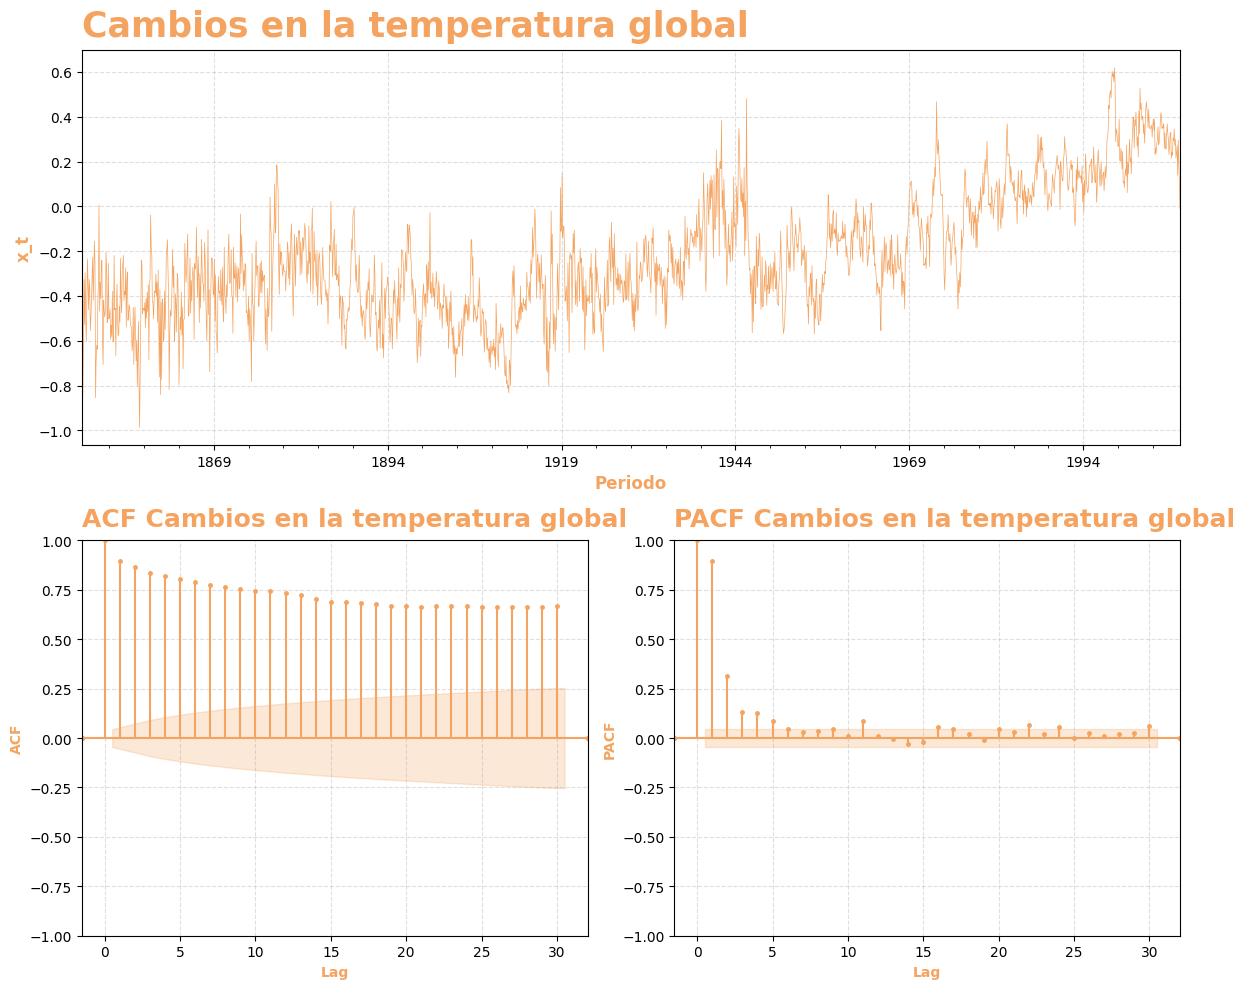

In [6]:
graphColor = 'sandybrown'
columna = 'Temp'
nombre = 'Cambios en la temperatura global'

# Crear nuestra figura con un GridSpec para acomodar los gráficos
fig = plt.figure(figsize=(12, 10)) # Tamaño de toda la figura
gs = fig.add_gridspec(2, 2) # Enrejado de 2 filas y 2 columnas

# Gráfico superior ocupando fila completa
ax0 = fig.add_subplot(gs[0, :]) # Subgráfico en la primera fila abarcando todas las columnas
df[columna].plot(color = graphColor, lw=.5)
ax0.set_title(nombre, loc='left', color = graphColor, fontweight = 'bold', size = 25,  pad=10)
ax0.set_xlabel('Periodo', color = graphColor, fontweight = 'bold', size=12,)
ax0.set_ylabel('x_t', color = graphColor, fontweight = 'bold', size = 12)
ax0.grid(True, linestyle='--', alpha=0.4)

# Gráfico inferior izquierdo (ACF)
ax1 = fig.add_subplot(gs[1, 0]) # Subgráfico en la segunda fila primera columna
plot_acf(df[columna], lags=30, marker = '.', title= '', ax=ax1, # OJO con el parámetro ax
         color=graphColor, vlines_kwargs={"colors": graphColor})
# Cambio de color al intervalo de confianza
ciACF = ax1.collections[1]
ciACF.set_color(graphColor)
ax1.set_title('ACF ' + nombre, loc='left', color = graphColor, fontweight = 'bold', size = 18,  pad=10)
ax1.set_xlabel('Lag', color = graphColor, fontweight = 'bold')
ax1.set_ylabel('ACF', color = graphColor, fontweight = 'bold')
ax1.grid(True, linestyle='--', alpha=0.4)

# Gráfico inferior derecho (PACF)
ax2 = fig.add_subplot(gs[1, 1])  # Subgráfico en la segunda fila segunda columna
plot_pacf(df[columna], lags=30, marker = '.', title= '', ax=ax2,  # OJO con el parámetro ax
         color=graphColor, vlines_kwargs={"colors": graphColor})
# Cambio de color al intervalo de confianza
ciACF = ax2.collections[1]
ciACF.set_color(graphColor)
ax2.set_title('PACF ' + nombre, loc='left', color = graphColor, fontweight = 'bold', size = 18,  pad=10)
ax2.set_xlabel('Lag', color = graphColor, fontweight = 'bold')
ax2.set_ylabel('PACF', color = graphColor, fontweight = 'bold')
ax2.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout() # Prevenir traslape de etiquetas y títulos
plt.show()

In [7]:
# Ajuste de un modelo SARIMA automático con p, q, P, Q de 0 a 5
sarima_model = auto_arima(df['Temp'],
                          start_p=1, max_p=2,
                          start_q=1, max_q=2,
                          information_criterion = 'aic',
                          stepwise = True, # Prueba con algoritmo stepwise
                          approximation = True, # Usar aproximación para verosimilitud ágil (menos precisa)
                          with_intercept = True, # Que incluya un intercepto
                          trace = True, # Imprimir resultados de cada paso
                          # Parámetros de estacionalidad
                          seasonal=True,
                          m = 12,
                          start_P=1, max_P=2,
                          start_Q=1, max_Q=2
                          )

print(sarima_model.summary())

Performing stepwise search to minimize aic
 ARIMA(1,1,1)(1,0,1)[12] intercept   : AIC=-2942.455, Time=7.37 sec
 ARIMA(0,1,0)(0,0,0)[12] intercept   : AIC=-2570.249, Time=0.67 sec
 ARIMA(1,1,0)(1,0,0)[12] intercept   : AIC=-2819.369, Time=1.03 sec
 ARIMA(0,1,1)(0,0,1)[12] intercept   : AIC=-2917.423, Time=1.18 sec
 ARIMA(0,1,0)(0,0,0)[12]             : AIC=-2572.236, Time=0.10 sec
 ARIMA(1,1,1)(0,0,1)[12] intercept   : AIC=-2944.460, Time=1.95 sec
 ARIMA(1,1,1)(0,0,0)[12] intercept   : AIC=-2946.454, Time=0.64 sec
 ARIMA(1,1,1)(1,0,0)[12] intercept   : AIC=-2944.460, Time=2.14 sec
 ARIMA(0,1,1)(0,0,0)[12] intercept   : AIC=-2918.141, Time=0.54 sec
 ARIMA(1,1,0)(0,0,0)[12] intercept   : AIC=-2819.367, Time=0.13 sec
 ARIMA(2,1,1)(0,0,0)[12] intercept   : AIC=-2979.500, Time=1.51 sec
 ARIMA(2,1,1)(1,0,0)[12] intercept   : AIC=-2979.754, Time=5.71 sec
 ARIMA(2,1,1)(2,0,0)[12] intercept   : AIC=-2970.481, Time=10.34 sec
 ARIMA(2,1,1)(1,0,1)[12] intercept   : AIC=-2970.391, Time=4.79 sec
 ARI

In [8]:
# Obtener valores ajustados y predicciones
modelo = sarima_model
pasos = 300
nombreSerie = 'Cambio en la temperatura global'
nombreModelo = 'SARIMA (Auto)'

# Obtener los valores ajustados a los datos históricos
df['ajuste'] = modelo.fittedvalues()
df['residuals'] = modelo.resid()
df['residuals_sq'] = df['residuals']**2

# Excluir el primer valor del ajuste (estableciéndolo a NaN)
df['ajuste'].iloc[0:13,] = np.nan

# Generar predicciones con intervalos de confianza al 95%
forecast, intConf = modelo.predict(n_periods=pasos, return_conf_int=True)
dfForSarima = pd.DataFrame({
    'forecast': forecast,
    'cotaInf': intConf[:, 0],
    'cotaSup': intConf[:, 1]
})

dfForSarima.head()

/tmp/ipykernel_816/2773692524.py:13: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df['ajuste'].iloc[0:13,] = np.nan


,forecast,cotaInf,cotaSup
2008-01-01,0.099180,-0.114472,0.312832
2008-02-01,0.133081,-0.108457,0.374620
2008-03-01,0.152819,-0.104905,0.410543
2008-04-01,0.158932,-0.111094,0.428958
2008-05-01,0.154036,-0.125943,0.434015


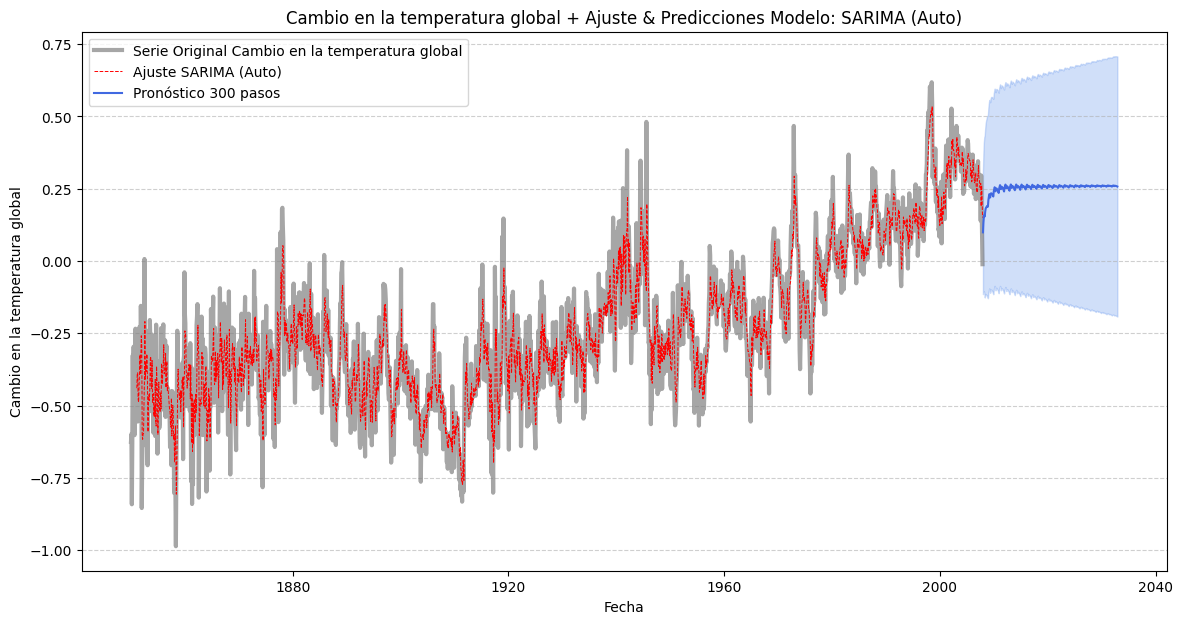

In [9]:
plt.figure(figsize=(14, 7))
# Gráfico Serie Original
plt.plot(df.index, df['Temp'], label='Serie Original ' + nombreSerie, color = 'gray', lw = 3, alpha = 0.7)
# Gráfico de Valores ajustados
plt.plot(df.index, df['ajuste'], label='Ajuste ' + nombreModelo, color = 'red', linestyle='--', lw = 0.7)
# Gráfico Pronóstico puntual
plt.plot(dfForSarima.index, dfForSarima['forecast'], label='Pronóstico ' + str(pasos) + ' pasos', color='royalblue')
# Gráfico Intervalos de confianza
plt.fill_between(dfForSarima.index, dfForSarima['cotaInf'], dfForSarima['cotaSup'], color='cornflowerblue', alpha=0.3)

plt.title(nombreSerie + ' + Ajuste & Predicciones Modelo: ' + nombreModelo)
plt.xlabel('Fecha')
plt.ylabel(nombreSerie)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

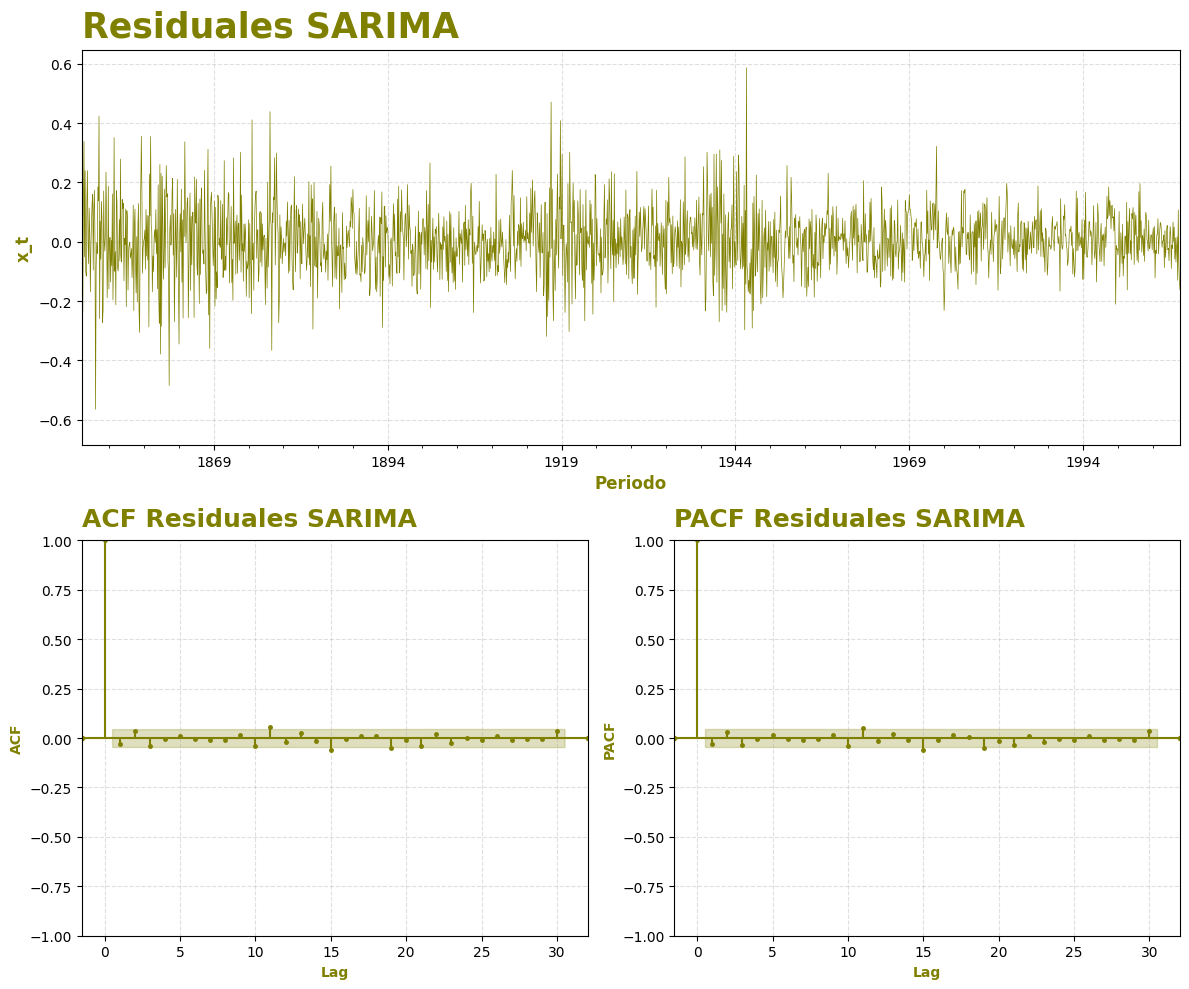

In [10]:
graphColor = 'olive'
columna = 'residuals'
nombre = 'Residuales SARIMA'

# Crear nuestra figura con un GridSpec para acomodar los gráficos
fig = plt.figure(figsize=(12, 10)) # Tamaño de toda la figura
gs = fig.add_gridspec(2, 2) # Enrejado de 2 filas y 2 columnas

# Gráfico superior ocupando fila completa
ax0 = fig.add_subplot(gs[0, :]) # Subgráfico en la primera fila abarcando todas las columnas
df[columna].plot(color = graphColor, lw=.5)
ax0.set_title(nombre, loc='left', color = graphColor, fontweight = 'bold', size = 25,  pad=10)
ax0.set_xlabel('Periodo', color = graphColor, fontweight = 'bold', size=12,)
ax0.set_ylabel('x_t', color = graphColor, fontweight = 'bold', size = 12)
ax0.grid(True, linestyle='--', alpha=0.4)

# Gráfico inferior izquierdo (ACF)
ax1 = fig.add_subplot(gs[1, 0]) # Subgráfico en la segunda fila primera columna
plot_acf(df[columna], lags=30, marker = '.', title= '', ax=ax1, # OJO con el parámetro ax
         color=graphColor, vlines_kwargs={"colors": graphColor})
# Cambio de color al intervalo de confianza
ciACF = ax1.collections[1]
ciACF.set_color(graphColor)
ax1.set_title('ACF ' + nombre, loc='left', color = graphColor, fontweight = 'bold', size = 18,  pad=10)
ax1.set_xlabel('Lag', color = graphColor, fontweight = 'bold')
ax1.set_ylabel('ACF', color = graphColor, fontweight = 'bold')
ax1.grid(True, linestyle='--', alpha=0.4)

# Gráfico inferior derecho (PACF)
ax2 = fig.add_subplot(gs[1, 1])  # Subgráfico en la segunda fila segunda columna
plot_pacf(df[columna], lags=30, marker = '.', title= '', ax=ax2,  # OJO con el parámetro ax
         color=graphColor, vlines_kwargs={"colors": graphColor})
# Cambio de color al intervalo de confianza
ciACF = ax2.collections[1]
ciACF.set_color(graphColor)
ax2.set_title('PACF ' + nombre, loc='left', color = graphColor, fontweight = 'bold', size = 18,  pad=10)
ax2.set_xlabel('Lag', color = graphColor, fontweight = 'bold')
ax2.set_ylabel('PACF', color = graphColor, fontweight = 'bold')
ax2.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout() # Prevenir traslape de etiquetas y títulos
plt.show()

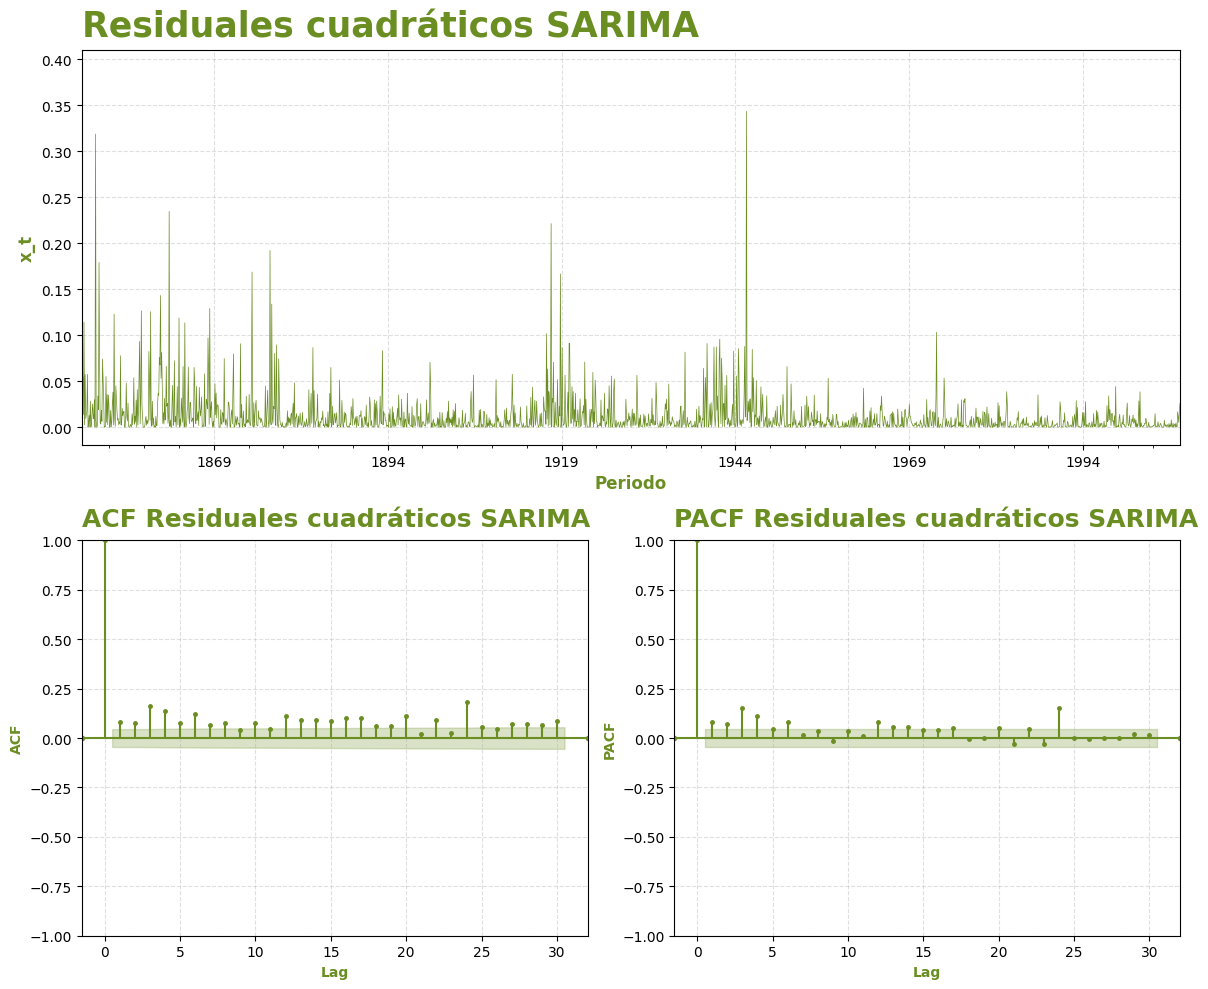

In [11]:
graphColor = 'olivedrab'
columna = 'residuals_sq'
nombre = 'Residuales cuadráticos SARIMA'

# Crear nuestra figura con un GridSpec para acomodar los gráficos
fig = plt.figure(figsize=(12, 10)) # Tamaño de toda la figura
gs = fig.add_gridspec(2, 2) # Enrejado de 2 filas y 2 columnas

# Gráfico superior ocupando fila completa
ax0 = fig.add_subplot(gs[0, :]) # Subgráfico en la primera fila abarcando todas las columnas
df[columna].plot(color = graphColor, lw=.5)
ax0.set_title(nombre, loc='left', color = graphColor, fontweight = 'bold', size = 25,  pad=10)
ax0.set_xlabel('Periodo', color = graphColor, fontweight = 'bold', size=12,)
ax0.set_ylabel('x_t', color = graphColor, fontweight = 'bold', size = 12)
ax0.grid(True, linestyle='--', alpha=0.4)

# Gráfico inferior izquierdo (ACF)
ax1 = fig.add_subplot(gs[1, 0]) # Subgráfico en la segunda fila primera columna
plot_acf(df[columna], lags=30, marker = '.', title= '', ax=ax1, # OJO con el parámetro ax
         color=graphColor, vlines_kwargs={"colors": graphColor})
# Cambio de color al intervalo de confianza
ciACF = ax1.collections[1]
ciACF.set_color(graphColor)
ax1.set_title('ACF ' + nombre, loc='left', color = graphColor, fontweight = 'bold', size = 18,  pad=10)
ax1.set_xlabel('Lag', color = graphColor, fontweight = 'bold')
ax1.set_ylabel('ACF', color = graphColor, fontweight = 'bold')
ax1.grid(True, linestyle='--', alpha=0.4)

# Gráfico inferior derecho (PACF)
ax2 = fig.add_subplot(gs[1, 1])  # Subgráfico en la segunda fila segunda columna
plot_pacf(df[columna], lags=30, marker = '.', title= '', ax=ax2,  # OJO con el parámetro ax
         color=graphColor, vlines_kwargs={"colors": graphColor})
# Cambio de color al intervalo de confianza
ciACF = ax2.collections[1]
ciACF.set_color(graphColor)
ax2.set_title('PACF ' + nombre, loc='left', color = graphColor, fontweight = 'bold', size = 18,  pad=10)
ax2.set_xlabel('Lag', color = graphColor, fontweight = 'bold')
ax2.set_ylabel('PACF', color = graphColor, fontweight = 'bold')
ax2.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout() # Prevenir traslape de etiquetas y títulos
plt.show()

## **Modelo GARCH**

In [12]:
model_garch = arch_model(df['residuals'], vol='GARCH', p=1, q=1)
model_fit = model_garch.fit(disp='off')
print(model_fit.summary())

                     Constant Mean - GARCH Model Results                      
Dep. Variable:              residuals   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:                1639.76
Distribution:                  Normal   AIC:                          -3271.51
Method:            Maximum Likelihood   BIC:                          -3249.32
                                        No. Observations:                 1896
Date:                Sun, Jun 28 2026   Df Residuals:                     1895
Time:                        06:45:59   Df Model:                            1
                                 Mean Model                                 
                 coef    std err          t      P>|t|      95.0% Conf. Int.
----------------------------------------------------------------------------
mu         5.0980e-03  2.213e-03      2.303  2.126e-02 [7.

/usr/local/lib/python3.12/dist-packages/arch/univariate/base.py:694: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 0.01203. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 10 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  self._check_scale(resids)


In [13]:
alpha0 = model_fit.params['omega']
alpha1 = model_fit.params['alpha[1]']
beta1 = model_fit.params['beta[1]']

In [14]:
# Inicializar columnas con ceros
df['h'] = 0.0
df['E'] = 0.0

# Get column index for 'h', 'E', and 'residuals_sq' to use with iloc
hCol = df.columns.get_loc('h')
ECol = df.columns.get_loc('E')
resSqCol = df.columns.get_loc('residuals_sq')

# Valores iniciales para h y E
df.iloc[0, hCol] = alpha0 / (1 - alpha1 - beta1)
df.iloc[0, ECol] = np.sqrt(df.iloc[0, hCol])

for i in range(1, len(df)):
    # GARCH(1,1) formula fpara varianza condicional:
    # h[i] = alpha_0 + alpha_1 * E[i-1]^2 + beta1 * h[i-1]
    df.iloc[i, hCol] = alpha0 + alpha1 * df.iloc[i-1, resSqCol] + beta1 * df.iloc[i-1, hCol]

    # La volatilidad condicional es la raíz cuadrada de la varianza condicional
    df.iloc[i, ECol] = np.sqrt(df.iloc[i, hCol])

# Retornos ajustados divididos por la desviación estándar condicional estimada por el modelo
# Si el GARCH es adecuado, estos residuales deberían ser ruido blanco sin autocorrelación.
df['residualGARCH'] = df['residuals'] / df['E']
# Calculemos residuales al cuadrado
df['residualGARCH_sq'] = df['residualGARCH']**2

df.head()

,Temp,ajuste,residuals,residuals_sq,h,E,residualGARCH,residualGARCH_sq
Fecha,,,,,,,,
1850-01-01,-0.625,NaN,-0.625000,0.390625,0.012024,0.109654,-5.699752,32.487169
1850-02-01,-0.598,NaN,0.027000,0.000729,0.030954,0.175937,0.153464,0.023551
1850-03-01,-0.841,NaN,-0.234027,0.054769,0.029064,0.170482,-1.372740,1.884416
1850-04-01,-0.632,NaN,0.117765,0.013869,0.030008,0.173229,0.679825,0.462161
1850-05-01,-0.326,NaN,0.338015,0.114254,0.028842,0.169828,1.990339,3.961448


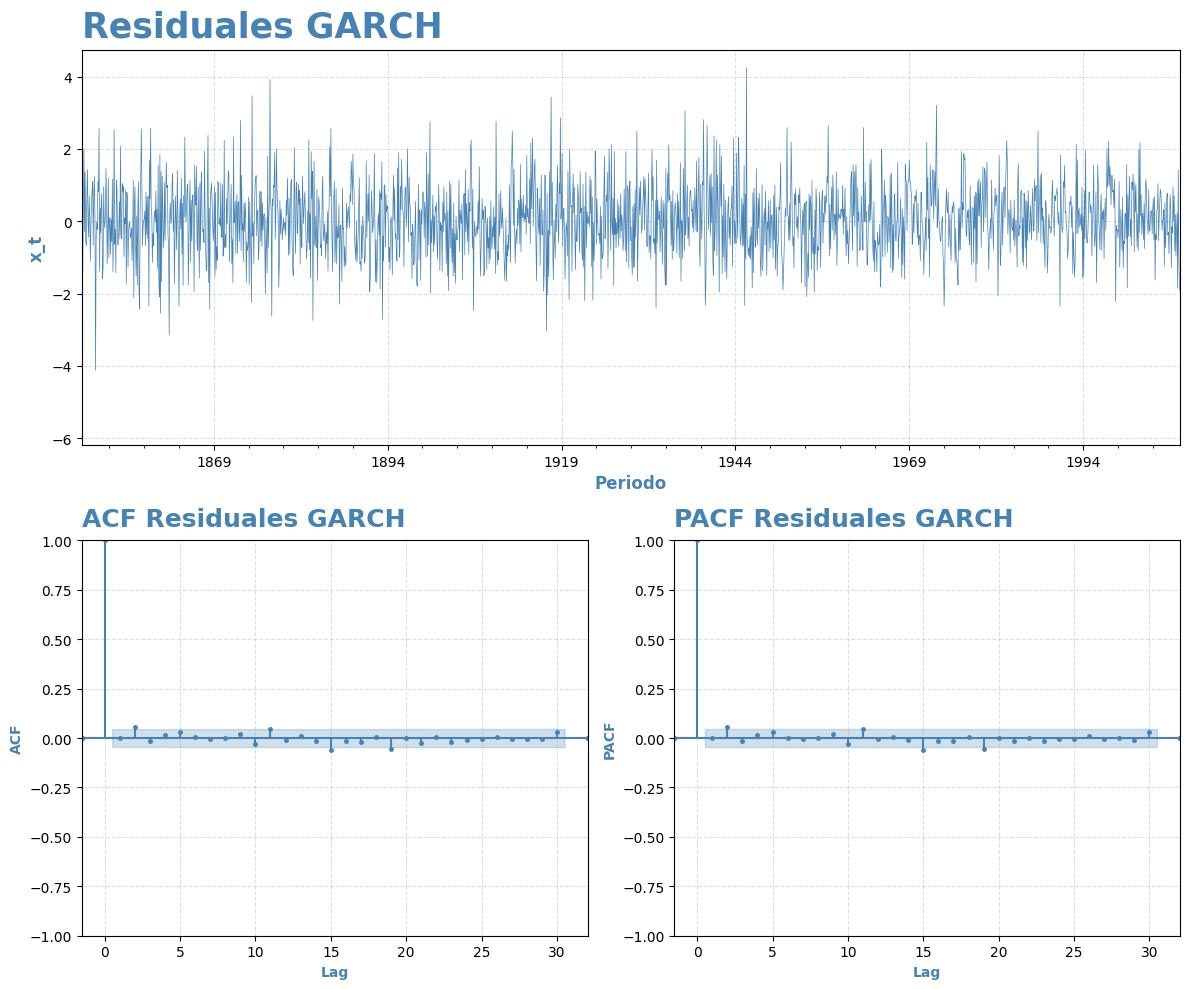

In [15]:
graphColor = 'steelblue'
columna = 'residualGARCH'
nombre = 'Residuales GARCH'

# Crear nuestra figura con un GridSpec para acomodar los gráficos
fig = plt.figure(figsize=(12, 10)) # Tamaño de toda la figura
gs = fig.add_gridspec(2, 2) # Enrejado de 2 filas y 2 columnas

# Gráfico superior ocupando fila completa
ax0 = fig.add_subplot(gs[0, :]) # Subgráfico en la primera fila abarcando todas las columnas
df[columna].plot(color = graphColor, lw=.5)
ax0.set_title(nombre, loc='left', color = graphColor, fontweight = 'bold', size = 25,  pad=10)
ax0.set_xlabel('Periodo', color = graphColor, fontweight = 'bold', size=12,)
ax0.set_ylabel('x_t', color = graphColor, fontweight = 'bold', size = 12)
ax0.grid(True, linestyle='--', alpha=0.4)

# Gráfico inferior izquierdo (ACF)
ax1 = fig.add_subplot(gs[1, 0]) # Subgráfico en la segunda fila primera columna
plot_acf(df[columna], lags=30, marker = '.', title= '', ax=ax1, # OJO con el parámetro ax
         color=graphColor, vlines_kwargs={"colors": graphColor})
# Cambio de color al intervalo de confianza
ciACF = ax1.collections[1]
ciACF.set_color(graphColor)
ax1.set_title('ACF ' + nombre, loc='left', color = graphColor, fontweight = 'bold', size = 18,  pad=10)
ax1.set_xlabel('Lag', color = graphColor, fontweight = 'bold')
ax1.set_ylabel('ACF', color = graphColor, fontweight = 'bold')
ax1.grid(True, linestyle='--', alpha=0.4)

# Gráfico inferior derecho (PACF)
ax2 = fig.add_subplot(gs[1, 1])  # Subgráfico en la segunda fila segunda columna
plot_pacf(df[columna], lags=30, marker = '.', title= '', ax=ax2,  # OJO con el parámetro ax
         color=graphColor, vlines_kwargs={"colors": graphColor})
# Cambio de color al intervalo de confianza
ciACF = ax2.collections[1]
ciACF.set_color(graphColor)
ax2.set_title('PACF ' + nombre, loc='left', color = graphColor, fontweight = 'bold', size = 18,  pad=10)
ax2.set_xlabel('Lag', color = graphColor, fontweight = 'bold')
ax2.set_ylabel('PACF', color = graphColor, fontweight = 'bold')
ax2.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout() # Prevenir traslape de etiquetas y títulos
plt.show()

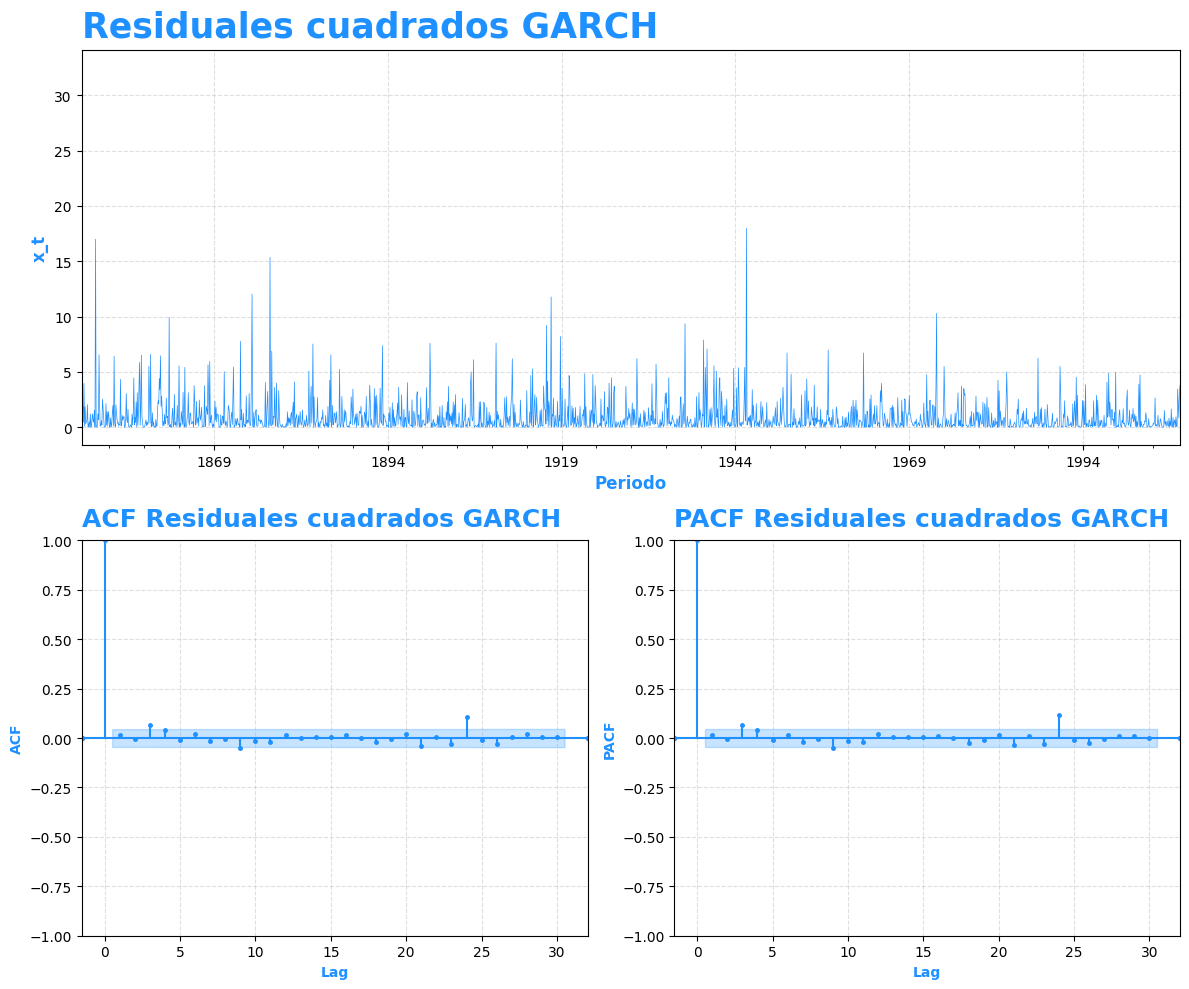

In [16]:
graphColor = 'dodgerblue'
columna = 'residualGARCH_sq'
nombre = 'Residuales cuadrados GARCH'

# Crear nuestra figura con un GridSpec para acomodar los gráficos
fig = plt.figure(figsize=(12, 10)) # Tamaño de toda la figura
gs = fig.add_gridspec(2, 2) # Enrejado de 2 filas y 2 columnas

# Gráfico superior ocupando fila completa
ax0 = fig.add_subplot(gs[0, :]) # Subgráfico en la primera fila abarcando todas las columnas
df[columna].plot(color = graphColor, lw=.5)
ax0.set_title(nombre, loc='left', color = graphColor, fontweight = 'bold', size = 25,  pad=10)
ax0.set_xlabel('Periodo', color = graphColor, fontweight = 'bold', size=12,)
ax0.set_ylabel('x_t', color = graphColor, fontweight = 'bold', size = 12)
ax0.grid(True, linestyle='--', alpha=0.4)

# Gráfico inferior izquierdo (ACF)
ax1 = fig.add_subplot(gs[1, 0]) # Subgráfico en la segunda fila primera columna
plot_acf(df[columna], lags=30, marker = '.', title= '', ax=ax1, # OJO con el parámetro ax
         color=graphColor, vlines_kwargs={"colors": graphColor})
# Cambio de color al intervalo de confianza
ciACF = ax1.collections[1]
ciACF.set_color(graphColor)
ax1.set_title('ACF ' + nombre, loc='left', color = graphColor, fontweight = 'bold', size = 18,  pad=10)
ax1.set_xlabel('Lag', color = graphColor, fontweight = 'bold')
ax1.set_ylabel('ACF', color = graphColor, fontweight = 'bold')
ax1.grid(True, linestyle='--', alpha=0.4)

# Gráfico inferior derecho (PACF)
ax2 = fig.add_subplot(gs[1, 1])  # Subgráfico en la segunda fila segunda columna
plot_pacf(df[columna], lags=30, marker = '.', title= '', ax=ax2,  # OJO con el parámetro ax
         color=graphColor, vlines_kwargs={"colors": graphColor})
# Cambio de color al intervalo de confianza
ciACF = ax2.collections[1]
ciACF.set_color(graphColor)
ax2.set_title('PACF ' + nombre, loc='left', color = graphColor, fontweight = 'bold', size = 18,  pad=10)
ax2.set_xlabel('Lag', color = graphColor, fontweight = 'bold')
ax2.set_ylabel('PACF', color = graphColor, fontweight = 'bold')
ax2.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout() # Prevenir traslape de etiquetas y títulos
plt.show()

In [17]:
# Crear 100 simulaciones de 300 pasos garch para sumar al pronóstico SARIMA

num_simulations = 100
dfSim = pd.DataFrame(index=dfForSarima.index) # DataFrame para almacenar los resultados de E de cada simulación

for sim in range(num_simulations):
    # Crear la columna w con muestras de ruido blanco gaussiano para esta simulación
    w_sim = np.random.normal(size=pasos)

    # Inicializar columnas para la varianza (h) y volatilidad (E) condicional para esta simulación
    h_sim = np.zeros(pasos)
    E_sim = np.zeros(pasos)

    # Crear un DataFrame temporal para la simulación actual
    dfSim_temp = pd.DataFrame({'w': w_sim, 'h': h_sim, 'E': E_sim})

    # Establecer los valores iniciales para h y E
    dfSim_temp.loc[0, 'h'] = alpha0 / (1 - alpha1 - beta1)
    dfSim_temp.loc[0, 'E'] = np.sqrt(dfSim_temp.loc[0, 'h'])

    # Iterar a partir de la segunda fila para actualizar 'h' y 'E'
    for i in range(1, len(dfSim_temp)):
        # h[i] = alpha_0 + alpha_1 * E[i-1]^2 + beta1 * h[i-1]
        dfSim_temp.loc[i, 'h'] = alpha0 + alpha1 * (dfSim_temp.loc[i-1, 'E']**2) + beta1 * dfSim_temp.loc[i-1, 'h']

        # E[i] = w[i] * sqrt(h[i])
        dfSim_temp.loc[i, 'E'] = dfSim_temp.loc[i, 'w'] * np.sqrt(dfSim_temp.loc[i, 'h'])

    # Sumar el forecast de dfForSarima a los valores de E de esta simulación
    dfSim_temp['E'] = dfSim_temp['E'] + dfForSarima['forecast'].values

    # Almacenar la columna 'E' de esta simulación en el DataFrame principal de simulaciones
    dfSim[f'Sim_{sim+1}'] = dfSim_temp['E'].values # .values para evitar problemas de alineación de índices

dfSim.head()

,Sim_1,Sim_2,Sim_3,Sim_4,Sim_5,Sim_6,Sim_7,Sim_8,Sim_9,Sim_10,...,Sim_91,Sim_92,Sim_93,Sim_94,Sim_95,Sim_96,Sim_97,Sim_98,Sim_99,Sim_100
2008-01-01,0.208834,0.208834,0.208834,0.208834,0.208834,0.208834,0.208834,0.208834,0.208834,0.208834,...,0.208834,0.208834,0.208834,0.208834,0.208834,0.208834,0.208834,0.208834,0.208834,0.208834
2008-02-01,-0.001658,0.195534,0.224722,0.072620,0.202340,0.148462,0.175466,0.042156,0.030392,0.134088,...,0.152163,0.147815,0.392299,-0.019556,0.173532,0.080309,0.217329,0.174642,0.053115,0.299424
2008-03-01,0.067717,0.310404,0.119624,0.073071,0.310986,0.121005,0.003606,0.314780,0.178102,0.154601,...,0.017512,0.155777,0.216963,0.134787,0.179270,0.143434,0.001976,0.155009,0.051041,0.154578
2008-04-01,0.262144,0.103600,0.086293,0.002503,0.157405,0.309720,0.288392,0.014826,0.087463,0.113553,...,0.194549,0.181310,0.159591,0.106657,0.433803,-0.000031,0.164767,0.352610,0.095793,0.036645
2008-05-01,0.251894,0.116359,0.215931,0.166602,0.242152,0.101819,0.265709,0.076076,0.271283,0.132865,...,0.310787,0.063562,0.235253,0.069280,0.281993,0.106591,0.251711,0.217525,0.135451,0.175426


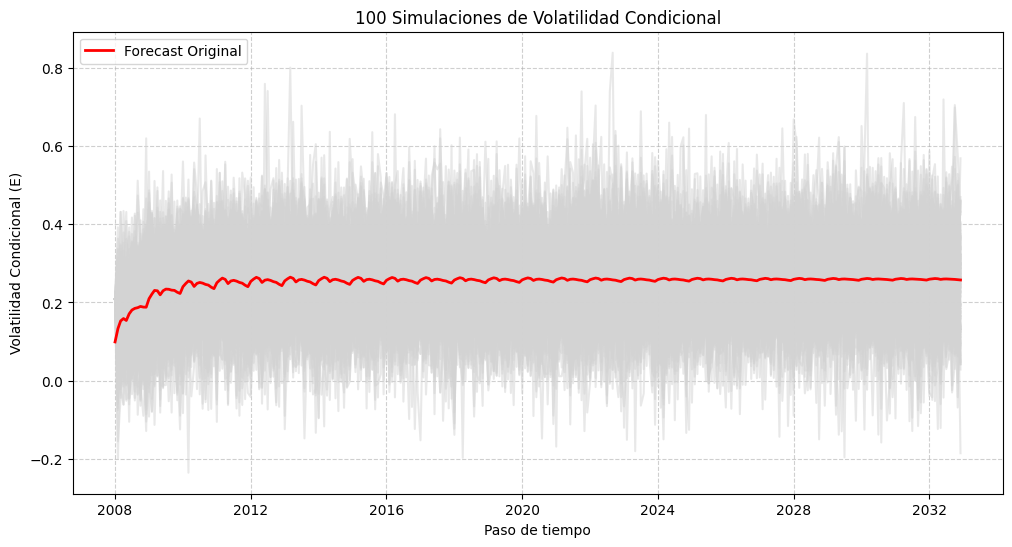

In [18]:
plt.figure(figsize=(12, 6))
for col in dfSim.columns:
    plt.plot(dfSim.index, dfSim[col], color='lightgray', alpha=0.5)

# Plot the original forecast from dfForSarima
plt.plot(dfForSarima.index, dfForSarima['forecast'], color='red', linewidth=2, label='Forecast Original')

plt.title('100 Simulaciones de Volatilidad Condicional')
plt.xlabel('Paso de tiempo')
plt.ylabel('Volatilidad Condicional (E)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()